 # <b>Przedmiot: Analiza Danych Przestrzennych </b>
# <b>Zadanie: Projekt końcowy</b>

<b>Cel: Celem projektu jest wizualizacja danych dotyczących optymalności rozmieszczenia przystanków autobusowych w Inowrocławiu w celu późniejszego wyznaczenia lokalizacji pięciu nowych przystanków które w jak jak największym stopniu poprawią komfort życia mieszkanców.</b>

<b>Opis problemu </b>

Wcielam się w rolę zespołu władz miejskich, który na podstawie danych dotyczących lokalizacji przystanków autobusowych i tras poszczególnych linii komunikacji miejskiej w mieście Inowrocław chce odpowiedzieć na poniższe pytania badawcze:
- Jak rozmieszczone są przystanki autobusowe względem głównych punktów użyteczności publicznej (szkół, uniwersytetów, urzędów, miejsc kultury i rozrywki, centra handlowego itd.)?
- Jakie linie autobusowe, mają najmniej przystanków w stosunku do długości swojej trasy?
- Czy istnieją przystanki, które są przeciążone (obsługują zbyt wiele linii)?
- Gdzie można by zlokalizować nowe przystanki, aby zwiększyć dostępność komunikacji miejskiej na poodstawie trzech powyższych wytycznych?

Przed przystąpieniem do analizy warto odpowiedzieć sobie na jeszcze jedno pytanie - jaka odłegłość pomiędzy przystankami komunikacji miejskiej, czy też od kluczowych budynków miejskich do najbliższego przystanku powinna być uznana za prawidłową? Z moich poszukiwań wynika, że często przyjmowaną odległością jest 400 metrów, taką więc też odległość przyjąłem za graniczną w dalszych obliczeniach.

<b> Źródła danych: </b>
- Dane o przystankach <i>(przystanki.csv)</i> zostały pobrane [ze strony rządowej dane.gov](https://dane.gov.pl/pl/dataset/2820,wykaz-przystankow-w-inowroclawiu/resource/52957/table?page=1&per_page=20&q=&sort=). Oryginalnie plik ten zawierał o kilka kolumn więcej niż nasze dane dołączone do tego projektu - usunąłem je, ponieważ nie były one użyteczne.
- Dane o budynkach użyteczności publicznej <i>(budynki.csv)</i> zostały ręcznie przeze mnie wybrane i zweryfikowane.
- Rozkład linii autobusowych wraz z ich długością oraz liczbą przystanków <i>(trasy.csv)</i> został opracowany na podstawie wspomnianego wcześniej pliku <i>przystanki.csv</i> oraz [oficjalnej strony MPK Inowrocław](http://www.bus.inowroclaw.pl/)]. Jak wspomniałem plik ten zawiera informacje o długościach poszczególnych linii, jednak w podlinkowym przez nas źródle takiej informacji nigdzie nie ma. Jest tak, ponieważ długość każdej linii (w obu kierunkach) "zmierzyłem" samodzielnie odtwarzajac każdą trasę na mapach google.

Dane poczatkowe posiadały polskie znaki diaktryczne (zarówno te plikach pobranych z internetu, jak i w naszych autorskich, jednak ze względu na różne komplikacje, które w zwiazku z nimi występowały, zdecydowałem się na usunięcie polskich liter z danych.

<b> Importy </b>

In [1]:
import shapely
import folium
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import networkx as nx
import geopandas as gpd
import contextily as ctx
import requests
import json
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from shapely.geometry import Point, Polygon, LineString
from folium.plugins import MarkerCluster, HeatMap

<b> Wczytanie danych </b>

In [2]:
przystanki = pd.read_csv("przystanki.csv",encoding="ISO-8859-2", sep=";", skipinitialspace=True)
print(przystanki)
budynki = pd.read_csv("budynki.csv",encoding="ISO-8859-2", sep=",", skipinitialspace=True)
print(budynki)
trasy = pd.read_csv("trasy.csv", encoding="UTF-8", sep=",", skipinitialspace=True)
print(trasy)

     Numer przystanku                                      Nazwa       lat  \
0                   1                             Dworzec PKP 1   52.80601   
1                   2                             Dworzec PKP  2  52.80574   
2                   4     Dworcowa  Grabskiego - kier. Kopernika  52.80477   
3                   5  Kopernika Wawrzyniaka - kier. Narutowicza  52.80149   
4                   6    Kopernika Narutowicza - kier. Ratuszowa  52.79900   
..                ...                                        ...       ...   
138               252        Miechowicka szpital kier. Poznanska  52.77897   
139               253       Wielkopolska cmentarz kier. Matewska  52.76145   
140               254    Wielkopolska cmentarz  kier. Szymborska  52.76168   
141               255              Ziarniaka kier. Czarnieckiego  52.79245   
142               169                      Glempa Niepodleglosci  52.78604   

         long               Nr linii      Kierunek ruchu  
0   

<b> Przed przejściem do analiz spójrzmy na mapę statyczną prezentującą układ przystanków i linii autobusowych w Inowrocławiu </b>

C:\Users\Admin\AppData\Local\Temp\ipykernel_980\4065268161.py:82: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


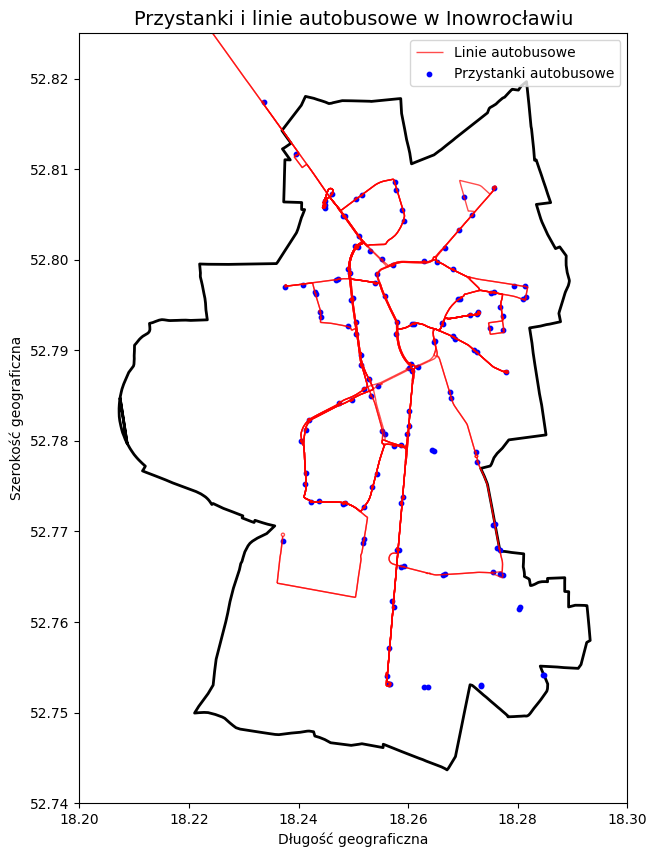

In [3]:
#OSM
url = "https://overpass-api.de/api/interpreter"
query = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["boundary"="administrative"]["admin_level"="8"](area.searchArea);
out geom;
"""

response = requests.get(url, params={"data": query})
data = response.json()

#Ekstrakcja współrzędnych miasta
def extract_coordinates(element):
    coordinates = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                coordinates.extend([(p["lon"], p["lat"]) for p in member["geometry"]])
    return coordinates

#Granice
boundaries = []
for element in data["elements"]:
    boundaries.extend(extract_coordinates(element))

if boundaries:
    city_boundary = Polygon(boundaries)
    gdf_boundary = gpd.GeoDataFrame(geometry=[city_boundary], crs="EPSG:4326")

przystanki = pd.read_csv("przystanki.csv", encoding="ISO-8859-2", sep=";", skipinitialspace=True)

przystanki["geometry"] = przystanki.apply(lambda row: Point(row["long"], row["lat"]), axis=1)
gdf_stops = gpd.GeoDataFrame(przystanki, geometry="geometry", crs="EPSG:4326")

#OSM
query_bus_routes = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
(
  relation["route"="bus"](area.searchArea);
  way["route"="bus"](area.searchArea);
);
out geom;
"""

response = requests.get(url, params={"data": query_bus_routes})
data = response.json()

#Ekstrakcja tras autobusowych
def extract_bus_routes(element):
    routes = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                routes.append([(p["lon"], p["lat"]) for p in member["geometry"]])
    elif "geometry" in element:
        routes.append([(p["lon"], p["lat"]) for p in element["geometry"]])
    return routes

bus_routes = []
for element in data["elements"]:
    bus_routes.extend(extract_bus_routes(element))

gdf_bus_routes = gpd.GeoDataFrame(
    geometry=[LineString(route) for route in bus_routes if len(route) > 1],
    crs="EPSG:4326"
)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_boundary.plot(ax=ax, color="none", edgecolor="black", linewidth=2, label="Granice miasta")
gdf_bus_routes.plot(ax=ax, color="red", linewidth=1, alpha=0.7, label="Linie autobusowe")
gdf_stops.plot(ax=ax, color="blue", markersize=10, label="Przystanki autobusowe")

ax.set_xlim(18.20, 18.30)
ax.set_ylim(52.74, 52.825)

ax.set_title("Przystanki i linie autobusowe w Inowrocławiu", fontsize=14)
ax.set_xlabel("Długość geograficzna")
ax.set_ylabel("Szerokość geograficzna")
ax.legend()


Na pierwszy rzut oka może wydawać się, że przede wszystkim tereny na wschodzie i południu Inowrocławia wymagają nowych przystanków, jednak w tym pierwszym przypadku jest to teren przede wszystkim tężni i parku Solankowego, po którym nie odbywa się ruch pojazdów mechanicznych, a także jest w tym miejscu sporo terenów niezamieszkałych. Na południowym-zachodzie miasta znajdują się duże zakłady przemysłowe, a z kolei na południowym-wschodzie - ponownie tereny należące administracyjnie do Inowrocławia, ale będące polami. 
[Jednocześnie w 2024 r. uległy zatwierdzeniu zmiany w planach zagospodarowania przestrzennego Inowrocławia w jego południowo-wschodniej części, na terenie której w niedalekiej przyszłości ma powstać nowe osiedle](https://www.radiopik.pl/2,120679,w-inowroclawiu-ma-powstac-nowe-osiedle-wielkosci), co należy mieć na uwadze podczas naszej analizy

<b> Analiza statystyczna (obliczenia + wykresy) </b>

In [4]:
# Funkcja pomocnicza do liczenia przystanków w promieniu 400m
def count_nearby_stops(lat, long, przystanki_df, radius=0.4):
    return sum(
        geodesic((lat, long), (row["lat"], row["long"])).km <= radius
        for _, row in przystanki_df.iterrows()
    )

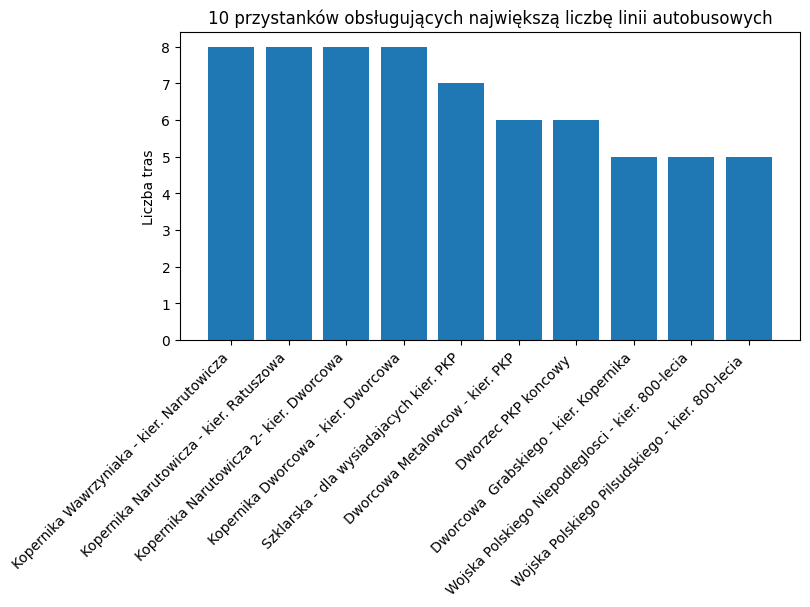

In [5]:
# 5 przystanków z największą liczbą obsługiwanych tras
przystanki["Nr linii"] = przystanki["Nr linii"].astype(str).apply(lambda x: x.split(","))
przystanki["Liczba tras"] = przystanki["Nr linii"].apply(len)
top_przystanki = przystanki.nlargest(10, "Liczba tras")
plt.figure(figsize=(8,4))
plt.bar(top_przystanki["Nazwa"], top_przystanki["Liczba tras"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Liczba tras")
plt.title("10 przystanków obsługujących największą liczbę linii autobusowych")
plt.show()

Wniosek - należy rozważyć zlokalizowanie nowych przystanków w okolicy przystanków:
- Kopernika Wawrzyniaka - kier. Narutowicza,
- Kopernika Narutowicza - kier. Ratuszowa,
- Kopernika Narutowicza 2- kier. Dworcowa,
- Kopernika Dworcowa - kier. Dworcowa.

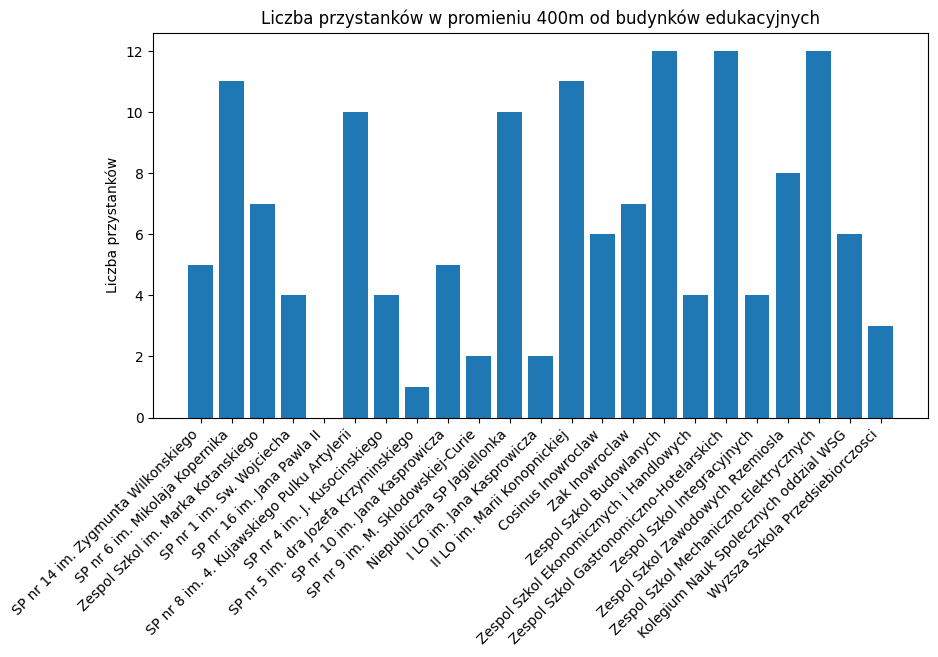

In [6]:
df_typ = budynki[budynki.iloc[:, 0] == "edukacja"].copy()
df_typ["Liczba przystanków"] = df_typ.apply(lambda row: count_nearby_stops(row["lat"], row["long"], przystanki), axis=1)
plt.figure(figsize=(10,5))
plt.bar(df_typ["nazwa"], df_typ["Liczba przystanków"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Liczba przystanków")
plt.title(f"Liczba przystanków w promieniu 400m od budynków edukacyjnych")
plt.show()

Wniosek - należy rozważyć zlokalizowanie nowych przystanków w okolicy:
- Szkoły Podstawowej nr 16,
- Szkoły Podstawowej nr 4,
- Szkoły Podstawowej nr 10,
- I Liceum Ogólnokształcącego.

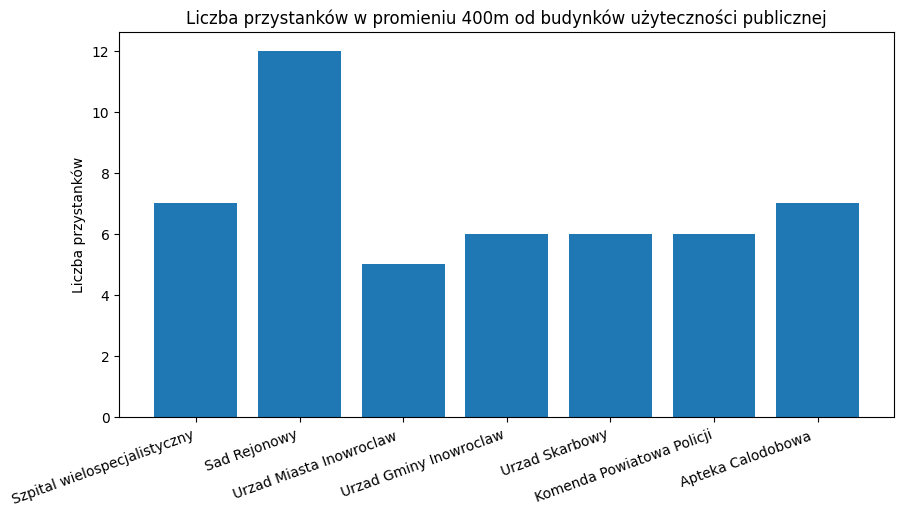

In [7]:
df_typ = budynki[budynki.iloc[:, 0] == "budynki uzytecznosci publicznej"].copy()
df_typ["Liczba przystanków"] = df_typ.apply(lambda row: count_nearby_stops(row["lat"], row["long"], przystanki), axis=1)
plt.figure(figsize=(10,5))
plt.bar(df_typ["nazwa"], df_typ["Liczba przystanków"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Liczba przystanków")
plt.title(f"Liczba przystanków w promieniu 400m od budynków użyteczności publicznej")
plt.show()

Wniosek - budynki użyteczności publicznej posiadają wystarczająco dużo przystanków autobusowych w swojej okolicy (najmniej 5), dlatego nie typuję otoczenia żadnego z nich na hipotetyczną lokalizację nowego przystanku.

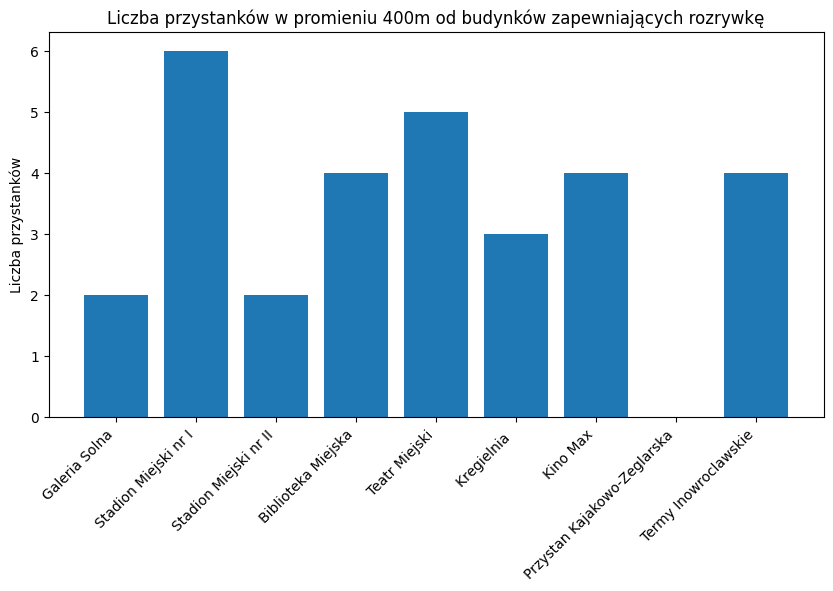

In [8]:
df_typ = budynki[budynki.iloc[:, 0] == "rozrywka"].copy()
df_typ["Liczba przystanków"] = df_typ.apply(lambda row: count_nearby_stops(row["lat"], row["long"], przystanki), axis=1)
plt.figure(figsize=(10,5))
plt.bar(df_typ["nazwa"], df_typ["Liczba przystanków"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Liczba przystanków")
plt.title(f"Liczba przystanków w promieniu 400m od budynków zapewniających rozrywkę")
plt.show()

Wniosek - należy rozważyć zlokalizowanie nowych przystanków w okolicy:
- Przystani Kajakowo-Żeglarskiej (szczególnie),
- Galerii Solnej (jedynej galerii handlowej w mieście),
- Stadionu Miejskiego nr II.

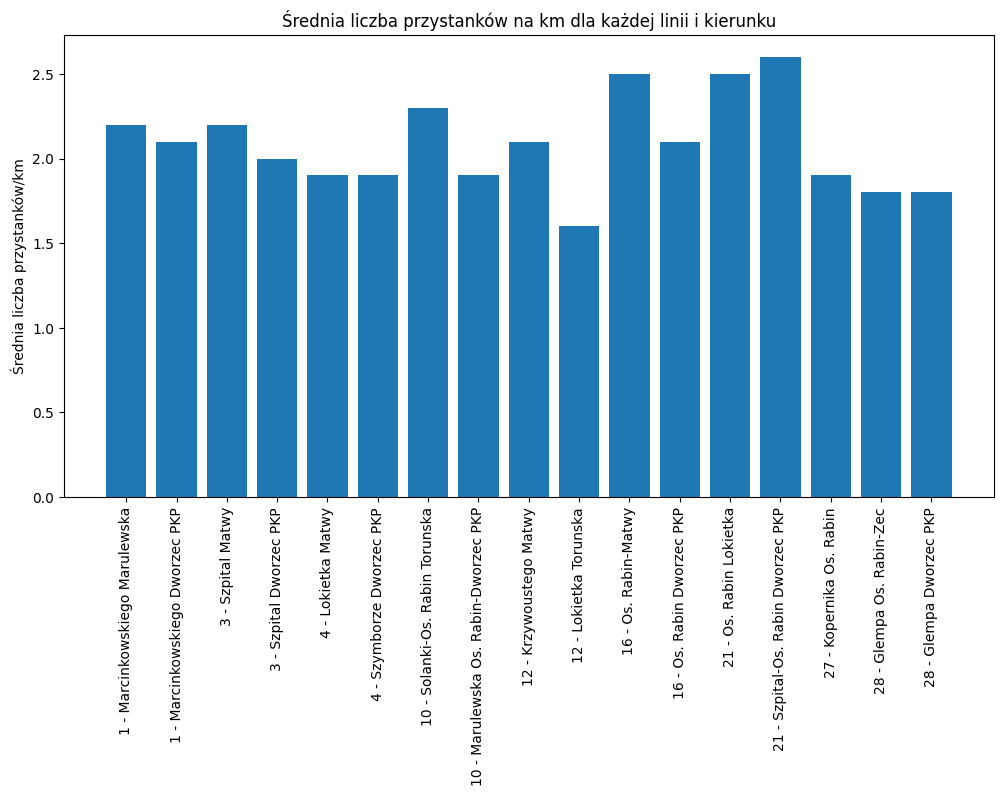

In [9]:
trasy["Średnia liczba przystanków/km"] = (trasy["Liczba przystankow"] / trasy["Dlugosc"]).round(1)
plt.figure(figsize=(12,6))
plt.bar(trasy["nr"].astype(str) + " - " + trasy["Kierunek"], trasy["Średnia liczba przystanków/km"])
plt.xticks(rotation=90)
plt.ylabel("Średnia liczba przystanków/km")
plt.title("Średnia liczba przystanków na km dla każdej linii i kierunku")
plt.show()

Wniosek:
- linia, która zdecydowanie odstaje od reszty w liczbie przystanków przypadających na 1km jest linia nr 12 w kierunku Łokietka Toruńska,
- również linie nr 27 i 28 mają mniejsze natężenie przystanków.

<b> Mapa dynamiczna z wszystkimi informacjami, które mogą pomóc w wyborze lokalizacji 5 nowych przystanków</b>

In [12]:
#Tworzenie mapy
center_lat, center_lon = 52.7984, 18.2612
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")
folium.TileLayer('cartodbpositron', name='CartoDB Positron').add_to(m)

selected_stops = przystanki[przystanki["Numer przystanku"].isin([5, 6, 25, 26])]
selected_buildings = budynki[budynki["nazwa"].isin([
    "SP nr 16 im. Jana Pawla II", "SP nr 4 im. J. Kusocinskiego", "SP nr 10 im. Jana Kasprowicza", 
    "I LO im. Jana Kasprowicza", "Przystan Kajakowo-Zeglarska", "Galeria Solna", "Stadion Miejski nr II"
])]

#Warstwa 1 - miejsca w otoczeniu, których brakuje przystanków
selected_stops["geometry"] = selected_stops.apply(lambda row: Point(row["long"], row["lat"]), axis=1)
selected_buildings["geometry"] = selected_buildings.apply(lambda row: Point(row["long"], row["lat"]), axis=1)
gdf_stops = gpd.GeoDataFrame(selected_stops, geometry="geometry", crs="EPSG:4326")
gdf_buildings = gpd.GeoDataFrame(selected_buildings, geometry="geometry", crs="EPSG:4326")

radius_layer = folium.FeatureGroup(name="Budynki", show=False)
#przystanki
for idx, row in gdf_stops.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color="green", icon="remove"),
        popup=f"Przystanek: {row['Nazwa']}"
    ).add_to(radius_layer)

#budynki
for idx, row in gdf_buildings.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color="green", icon="home"),
        popup=f"Budynek: {row['nazwa']}"
     ).add_to(radius_layer)

#promień
for idx, row in gdf_stops.iterrows():
    folium.Circle(
        location=[row.geometry.y, row.geometry.x],
        radius=400,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.2
    ).add_to(radius_layer)

#promień
for idx, row in gdf_buildings.iterrows():
    folium.Circle(
        location=[row.geometry.y, row.geometry.x],
        radius=400,
        color="green",
        fill=True,
        fill_color="green",
        fill_opacity=0.2
    ).add_to(radius_layer)
radius_layer.add_to(m)


#Warstwa 2 - heatmapa wszystkich przystanków
heat_data = przystanki[["lat", "long"]].values.tolist()
heatmap_layer = HeatMap(heat_data, radius=15, blur=10, min_opacity=0.5, name="Heatmapa przystanków", show=False)
heatmap_layer.add_to(m)


# Warstwa 3 - granice Inowrocławia
url = "https://overpass-api.de/api/interpreter"
query = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["boundary"="administrative"]["admin_level"="8"](area.searchArea);
out geom;
"""

response = requests.get(url, params={"data": query})
data = response.json()

#OSM
def extract_coordinates(element):
    """ Ekstrakcja współrzędnych z danych OSM """
    coordinates = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                coordinates.extend([(p["lon"], p["lat"]) for p in member["geometry"]])
    return coordinates

boundaries = []
for element in data["elements"]:
    boundaries.extend(extract_coordinates(element))

if boundaries:
    polygon = Polygon(boundaries) 
    gdf_boundary = gpd.GeoDataFrame(geometry=[polygon], crs="EPSG:4326")

    boundary_layer = folium.FeatureGroup(name="Granice Inowrocławia", show=False)

    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in boundaries], 
        color="black",
        weight=4,
        opacity=0.7,
    ).add_to(boundary_layer)

    boundary_layer.add_to(m)
    
#Warstwa 4 - linia autobusowa nr 12
url = "https://overpass-api.de/api/interpreter"
query_12 = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["route"="bus"]["ref"="12"](area.searchArea);
out geom;
"""
query_27 = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["route"="bus"]["ref"="27"](area.searchArea);
out geom;
"""
query_28 = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["route"="bus"]["ref"="28"](area.searchArea);
out geom;
"""
response12 = requests.get(url, params={"data": query_12})
data12 = response12.json()
response27 = requests.get(url, params={"data": query_27})
data27 = response27.json()
response28 = requests.get(url, params={"data": query_28})
data28 = response28.json()

def extract_bus_routes(element):
    coordinates = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                coordinates.append([(p["lon"], p["lat"]) for p in member["geometry"]])
    elif "geometry" in element:
        coordinates.append([(p["lon"], p["lat"]) for p in element["geometry"]])
    return coordinates

bus_routes_12 = []
bus_routes_27 = []
bus_routes_28 = []
for element12 in data12["elements"]:
    bus_routes_12.extend(extract_bus_routes(element12))

gdf_bus_12 = gpd.GeoDataFrame(
    geometry=[LineString(route12) for route12 in bus_routes_12 if len(route12) > 1],
    crs="EPSG:4326"
)

for element27 in data27["elements"]:
    bus_routes_27.extend(extract_bus_routes(element27))

gdf_bus_27 = gpd.GeoDataFrame(
    geometry=[LineString(route27) for route27 in bus_routes_27 if len(route27) > 1],
    crs="EPSG:4326"
)

for element28 in data28["elements"]:
    bus_routes_28.extend(extract_bus_routes(element28))

gdf_bus_28 = gpd.GeoDataFrame(
    geometry=[LineString(route28) for route28 in bus_routes_28 if len(route28) > 1],
    crs="EPSG:4326"
)

bus_layer = folium.FeatureGroup(name="Linie nr 12, 27 i 28", show=False)

for route12 in bus_routes_12:
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in route12], 
        color="gray",
        weight=4,
        opacity=0.8,
        tooltip="Linia nr 12"
    ).add_to(bus_layer)

for route28 in bus_routes_28:
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in route28], 
        color="blue",
        weight=3,
        opacity=0.7,
        tooltip="Linia nr 28"
    ).add_to(bus_layer)

for route27 in bus_routes_27:
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in route27], 
        color="purple",
        weight=3,
        opacity=0.6,
        tooltip="Linia nr 27"
    ).add_to(bus_layer)

bus_layer.add_to(m)

folium.LayerControl().add_to(m)

m

C:\Users\Admin\AppData\Local\Temp\ipykernel_980\2666036881.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_stops["geometry"] = selected_stops.apply(lambda row: Point(row["long"], row["lat"]), axis=1)
C:\Users\Admin\AppData\Local\Temp\ipykernel_980\2666036881.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  selected_buildings["geometry"] = selected_buildings.apply(lambda row: Point(row["long"], row["lat"]), axis=1)


Uwagi do mapy:
1. Niebieska droga prowadząca z Inowrocławia na północ (do Bydgoszczy) nie jest oczywiście trasą autobusów miejskich, tylko połączeniem PKSów, któe w OpenStreetMap było tak samo zidentyfikowane jak interesujące nas linie MZK.
2. Jak widać wszystkie najbardziej obciążone w mieście przystanki znajdują się bardzo blisko siebie i wynikają z faktu, że przez ten fragment ulicy Kopernika przebiega aż 8 z 9 linii autobusowych, jednocześnie wszystkie te przystanki są na tyle blisko siebie, że nie ma sensu lokalizować przy nich kolejnego.


<b> Wnioski </b>

Na podstawie przeprowadzonych analiz statystycznych oraz przestrzennych typujemy następujące lokalizacje nowych przystanków:
1.  Przystanek powstanie w okolicy przystani kajakowo-żeglarskiej, jednocześnie powstanie on w ramach lekkiego wydłużenia linii nr 12, dzięki czemu zyska ona jeden dodatkowy przystanek kosztem kilku metrów trasy.
2. Przystanek powstanie blisko Centrum miasta, jednocześnie na trasie nr 27 i w promieniu 400metrów do I LO.
3. Przystanek powstanie na linii nr 27 w jednoczesnej bliskości SP nr 4 i Galerii Solnej.
4. Przystanek powstanie w okolicy SP nr 16, co prawda obecnie nie przebiega w tej okolicy żadna linia autobusowa, ale w zwiazku z stałym rozrostem osiedla Toruńskiego, na terenie którego ta szkoła się znajduje, w przyszłości planowana jest modyfikacja trasy linii nr 12 tak aby obsługiwała również tę okolicę.
5. W związku z planową budową nowego osiedla na południe od szkoły podstawowej nr 10 również w jej okolicy powstałby jeden przystanek.

In [11]:
# Tworzenie mapy
center_lat, center_lon = 52.7984, 18.2612
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles="OpenStreetMap")
folium.TileLayer('cartodbpositron', name='CartoDB Positron').add_to(m)

gdf_stops = gpd.GeoDataFrame(przystanki, geometry="geometry", crs="EPSG:4326")

#1 warstwa - Granice Inowrocławia
url = "https://overpass-api.de/api/interpreter"
query = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["boundary"="administrative"]["admin_level"="8"](area.searchArea);
out geom;
"""

response = requests.get(url, params={"data": query})
data = response.json()

def extract_coordinates(element):
    """ Ekstrakcja współrzędnych z danych OSM """
    coordinates = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                coordinates.extend([(p["lon"], p["lat"]) for p in member["geometry"]])
    return coordinates

boundaries = []
for element in data["elements"]:
    boundaries.extend(extract_coordinates(element))

boundary_layer = folium.FeatureGroup(name="Granice Inowrocławia", show=True)

if boundaries:
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in boundaries], 
        color="black",
        weight=4,
        opacity=0.7,
        name="Granice Inowrocławia"
    ).add_to(boundary_layer)

    boundary_layer.add_to(m)

#2 warstwa - Linie autobusowe
bus_layer = folium.FeatureGroup(name="Trasy linii autobusowych", show=True)

query_bus_routes = """
[out:json];
area["name"="Inowrocław"]->.searchArea;
relation["route"="bus"](area.searchArea);
out geom;
"""

response_bus = requests.get(url, params={"data": query_bus_routes})
data_bus = response_bus.json()

def extract_bus_routes(element):
    coordinates = []
    if "members" in element:
        for member in element["members"]:
            if member["type"] == "way" and "geometry" in member:
                coordinates.append([(p["lon"], p["lat"]) for p in member["geometry"]])
    elif "geometry" in element:
        coordinates.append([(p["lon"], p["lat"]) for p in element["geometry"]])
    return coordinates

bus_routes = []
for element in data_bus["elements"]:
    bus_routes.extend(extract_bus_routes(element))

for route in bus_routes:
    folium.PolyLine(
        locations=[(lat, lon) for lon, lat in route], 
        color="blue",
        weight=2,
        opacity=0.6,
        tooltip="Linia autobusowa"
    ).add_to(bus_layer)

bus_layer.add_to(m)

#3 warstwa - Dotychczasowe przystanki
stop_cluster = MarkerCluster(name="Dotychczasowe przystanki", show=False).add_to(m)

for idx, row in gdf_stops.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        icon=folium.Icon(color="green", icon="ok"),
        popup=f"Przystanek: {row['Nazwa']}"
    ).add_to(stop_cluster)

#4 wastwa - nowe przystanki
new_stops = [
    (52.747917, 18.255000, "1. przy przystani"),
    (52.765440, 18.272393, "5. przy nowym osiedlu i SP10"),
    (52.783279, 18.245566, "3. przy galerii i SP4"),
    (52.7996633, 18.2609940, "4. w centrum, przy ILO"),
    (52.801010, 18.275714, "2. przy SP16 na przyszłość")
]

new_stop_layer = folium.FeatureGroup(name="Nowe wytypowane przystanki")

for lat, lon, name in new_stops:
    folium.Marker(
        location=[lat, lon],
        icon=folium.Icon(color="red", icon="plus"),
        tooltip=f"Wytypowany przystanek nr {name}"
    ).add_to(new_stop_layer)

new_stop_layer.add_to(m)

folium.LayerControl().add_to(m)

m